# PolyBLEP Oscillator

The PolyBLEP (Polynomial Bandlimited Step) oscillator produces antialiased waveforms
using polynomial corrections at discontinuities. This reduces aliasing without large
lookup tables, making it efficient and suitable for real-time synthesis.

This notebook demonstrates all features of `PolyBLEPOscillator`:
- All waveform shapes (sine, square, sawtooth, triangle)
- Antialiasing comparison with naive oscillators
- Pulse width modulation
- Iterator vs vectorized generation
- Runtime parameter changes
- Wave range conversion for LFOs
- Audio playback

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sounddevice as sd

from src.engine.generators.oscillators.oscillator_polyblep import (
    PolyBLEPOscillator,
    WaveShape,
)

plt.style.use("default")
plt.rcParams["figure.figsize"] = (14, 5)

SAMPLE_RATE = 44100
print("OK Imports loaded")

OK Imports loaded


## 1. All Waveforms

The `PolyBLEPOscillator` supports five waveform shapes via the `WaveShape` enum:
- **SINE** - Pure sine wave (no PolyBLEP correction needed)
- **SQUARE** - Bandlimited square with variable pulse width
- **SAWTOOTH_UP** - Rising sawtooth (bandlimited)
- **SAWTOOTH_DOWN** - Falling sawtooth (bandlimited)
- **TRIANGLE** - Triangle via integration of bandlimited square

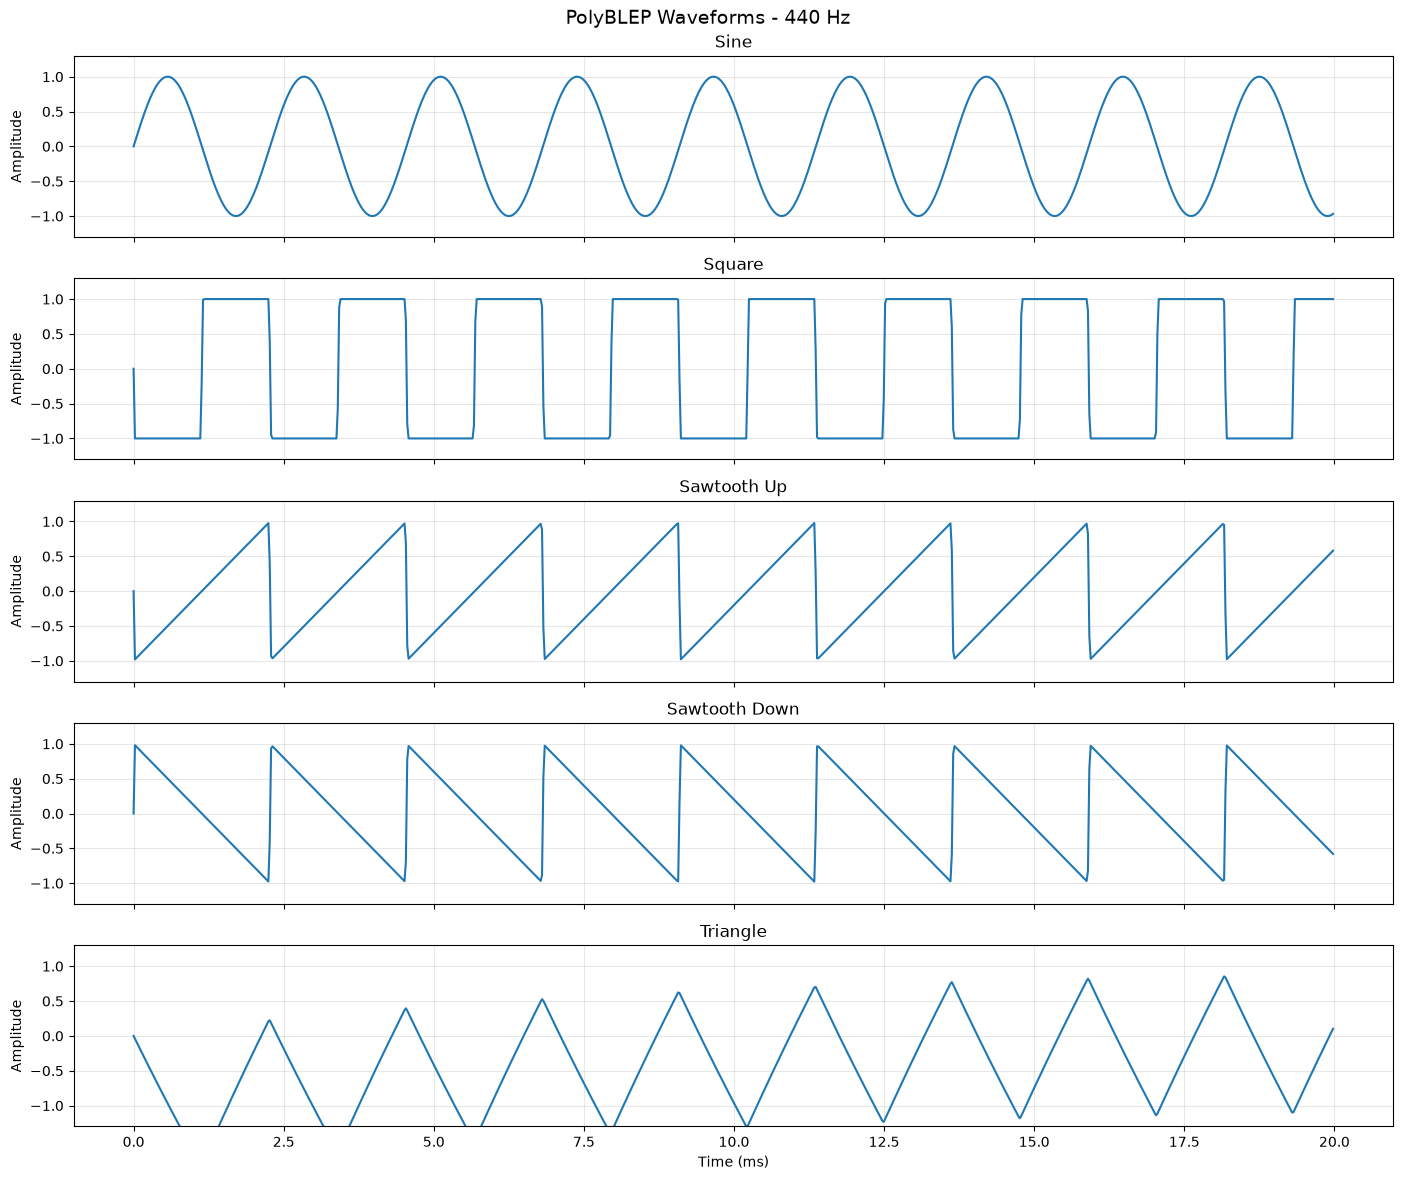

OK All 5 waveform shapes generated successfully


In [2]:
freq = 440
duration = 0.02  # 20ms
n_samples = int(SAMPLE_RATE * duration)
time = np.arange(n_samples) / SAMPLE_RATE * 1000  # ms

wave_shapes = [
    (WaveShape.SINE, "Sine"),
    (WaveShape.SQUARE, "Square"),
    (WaveShape.SAWTOOTH_UP, "Sawtooth Up"),
    (WaveShape.SAWTOOTH_DOWN, "Sawtooth Down"),
    (WaveShape.TRIANGLE, "Triangle"),
]

fig, axes = plt.subplots(len(wave_shapes), 1, figsize=(14, 12), sharex=True)
fig.suptitle(f"PolyBLEP Waveforms - {freq} Hz", fontsize=14)

for ax, (shape, name) in zip(axes, wave_shapes, strict=False):
    osc = PolyBLEPOscillator(
        frequency=freq,
        amplitude=1.0,
        gain_db=None,
        sample_rate=SAMPLE_RATE,
        wave_shape=shape,
    )
    samples = osc.get_samples(n_samples)
    ax.plot(time, samples, linewidth=1.5)
    ax.set_ylabel("Amplitude")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.3, 1.3)

axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

print("OK All 5 waveform shapes generated successfully")

## 2. Antialiasing: PolyBLEP vs Naive

PolyBLEP smooths discontinuities using polynomial corrections at transition points.
This dramatically reduces aliasing compared to naive (non-bandlimited) oscillators.

The left plot shows the waveform; the right plot shows the frequency spectrum (FFT).
Aliased harmonics appear as energy above the Nyquist limit.

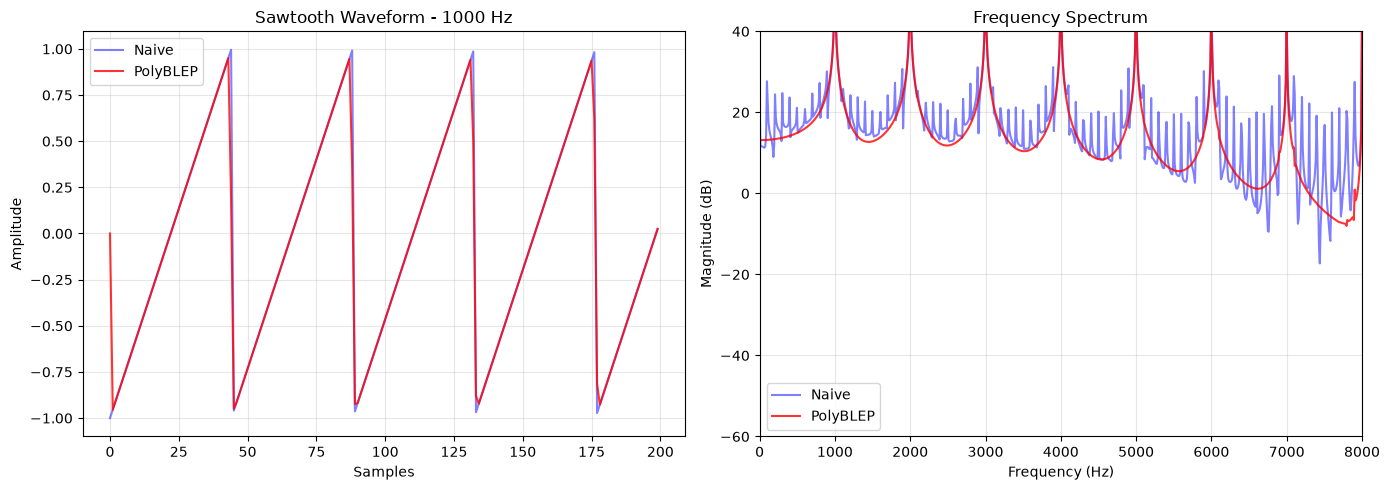

OK PolyBLEP reduces aliasing energy at high frequencies
  Naive:  sharp transitions create aliasing harmonics above Nyquist
  PolyBLEP: polynomial correction smooths discontinuities


In [3]:
freq = 1000
n_samples = 4096

# PolyBLEP sawtooth
osc_pb = PolyBLEPOscillator(
    frequency=freq,
    amplitude=1.0,
    gain_db=None,
    sample_rate=SAMPLE_RATE,
    wave_shape=WaveShape.SAWTOOTH_UP,
)
samples_pb = osc_pb.get_samples(n_samples)

# Naive sawtooth (sign of sine = instant transitions)
t = np.arange(n_samples) / SAMPLE_RATE
samples_naive = (2.0 * ((t * freq) % 1.0) - 1.0).astype(np.float32)

# FFT
freqs = np.fft.rfftfreq(n_samples, 1 / SAMPLE_RATE)
fft_pb = 20 * np.log10(np.abs(np.fft.rfft(samples_pb)) + 1e-10)
fft_naive = 20 * np.log10(np.abs(np.fft.rfft(samples_naive)) + 1e-10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Waveform
plot_samples = 200
ax1.plot(samples_naive[:plot_samples], "b-", alpha=0.5, label="Naive", linewidth=1.5)
ax1.plot(samples_pb[:plot_samples], "r-", alpha=0.8, label="PolyBLEP", linewidth=1.5)
ax1.set_title(f"Sawtooth Waveform - {freq} Hz")
ax1.set_xlabel("Samples")
ax1.set_ylabel("Amplitude")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Spectrum
ax2.plot(freqs, fft_naive, "b-", alpha=0.5, label="Naive")
ax2.plot(freqs, fft_pb, "r-", alpha=0.8, label="PolyBLEP")
ax2.set_title("Frequency Spectrum")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Magnitude (dB)")
ax2.set_xlim(0, 8000)
ax2.set_ylim(-60, 40)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("OK PolyBLEP reduces aliasing energy at high frequencies")
print("  Naive:  sharp transitions create aliasing harmonics above Nyquist")
print("  PolyBLEP: polynomial correction smooths discontinuities")

## 3. Pulse Width Modulation

The square wave supports variable pulse width (duty cycle) via the `pulsewidth` parameter.
- 0.5 = 50% duty cycle (standard square wave)
- < 0.5 = narrow pulse
- > 0.5 = wide pulse

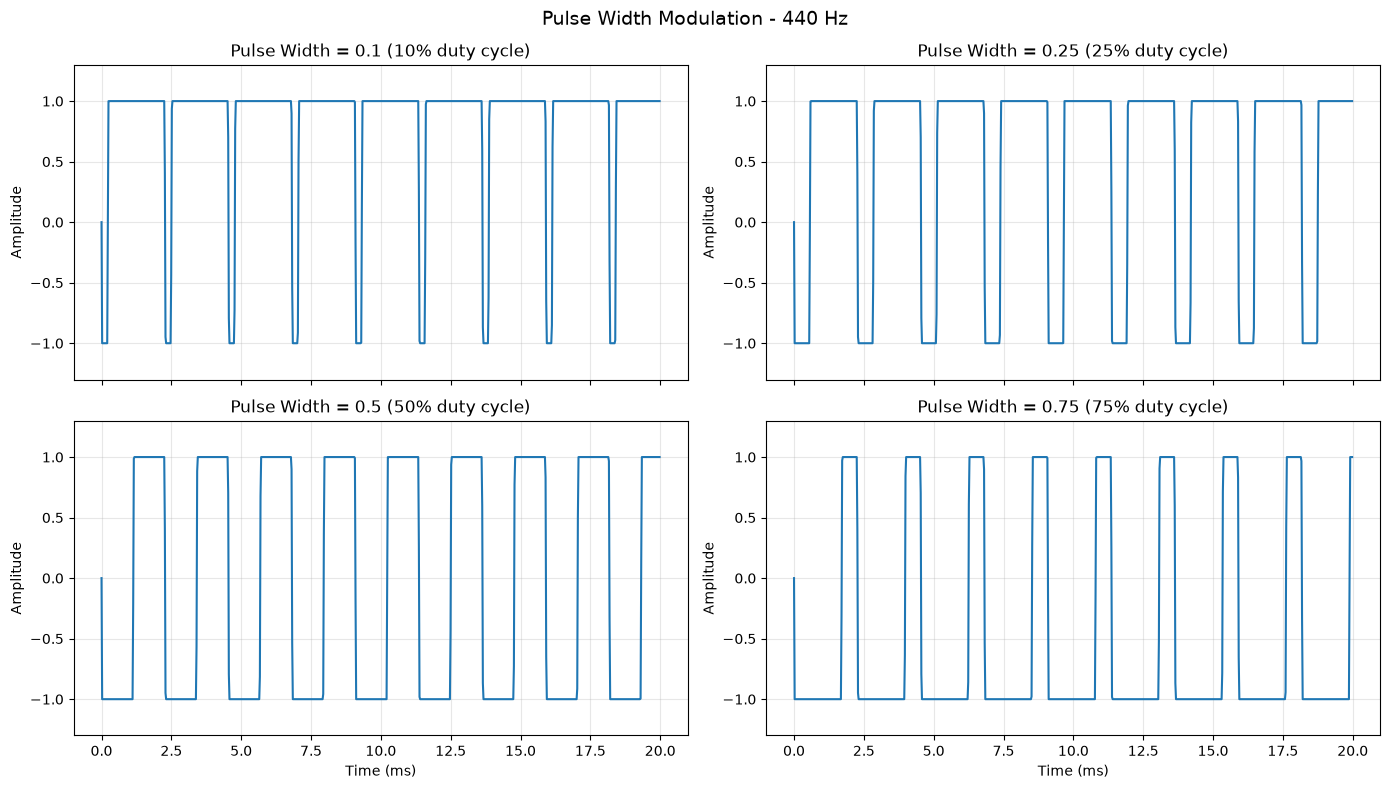

OK Pulse width modulation demonstrated
  0.5 = standard square wave (50% duty cycle)
  Varying pulsewidth changes the harmonic content of the square wave


In [4]:
freq = 440
duration = 0.02
n_samples = int(SAMPLE_RATE * duration)
time = np.arange(n_samples) / SAMPLE_RATE * 1000

pulsewidths = [0.1, 0.25, 0.5, 0.75]
labels = ["10%", "25%", "50%", "75%"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle(f"Pulse Width Modulation - {freq} Hz", fontsize=14)

for ax, pw, label in zip(axes.flat, pulsewidths, labels, strict=False):
    osc = PolyBLEPOscillator(
        frequency=freq,
        amplitude=1.0,
        gain_db=None,
        sample_rate=SAMPLE_RATE,
        wave_shape=WaveShape.SQUARE,
        pulsewidth=pw,
    )
    samples = osc.get_samples(n_samples)
    ax.plot(time, samples, linewidth=1.5)
    ax.set_title(f"Pulse Width = {pw} ({label} duty cycle)")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.3, 1.3)

axes[-1, 0].set_xlabel("Time (ms)")
axes[-1, 1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

print("OK Pulse width modulation demonstrated")
print("  0.5 = standard square wave (50% duty cycle)")
print("  Varying pulsewidth changes the harmonic content of the square wave")

## 4. Iterator vs Vectorized Generation

Two methods for generating samples:
- **Iterator** (`get_samples_iterator`): sample-by-sample, slower but flexible
- **Vectorized** (`get_samples_vectorized`): NumPy bulk operations, 50-85x faster

Both produce identical output for the same oscillator state.

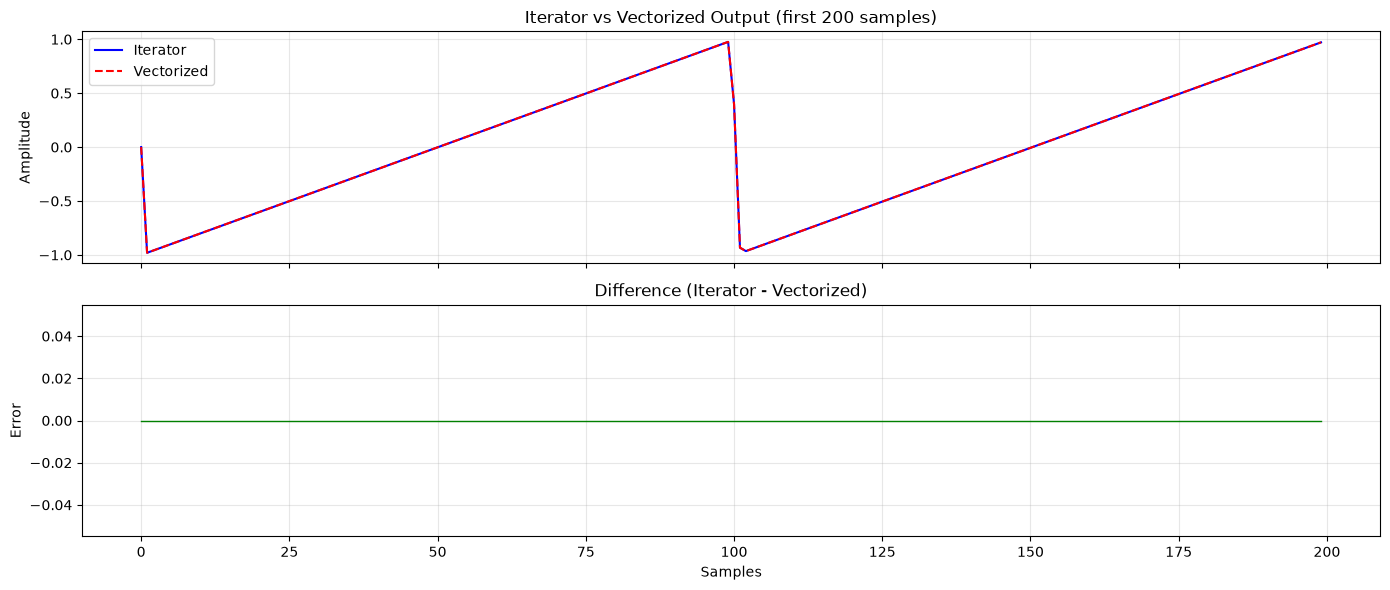

OK Max difference between modes: 0.00e+00
  Both methods produce identical output
  Use vectorized for performance, iterator for flexibility


In [5]:
n_samples = 1024

# Iterator mode
osc_iter = PolyBLEPOscillator(
    frequency=440,
    amplitude=1.0,
    gain_db=None,
    sample_rate=SAMPLE_RATE,
    wave_shape=WaveShape.SAWTOOTH_UP,
)
samples_iter = osc_iter.get_samples(n_samples, mode="iterator")

# Vectorized mode
osc_vec = PolyBLEPOscillator(
    frequency=440,
    amplitude=1.0,
    gain_db=None,
    sample_rate=SAMPLE_RATE,
    wave_shape=WaveShape.SAWTOOTH_UP,
)
samples_vec = osc_vec.get_samples(n_samples, mode="vectorized")

# Compare
max_diff = np.max(np.abs(samples_iter - samples_vec))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(samples_iter[:200], "b-", label="Iterator", linewidth=1.5)
ax1.plot(samples_vec[:200], "r--", label="Vectorized", linewidth=1.5)
ax1.set_title("Iterator vs Vectorized Output (first 200 samples)")
ax1.set_ylabel("Amplitude")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(samples_iter[:200] - samples_vec[:200], "g-", linewidth=1)
ax2.set_title("Difference (Iterator - Vectorized)")
ax2.set_xlabel("Samples")
ax2.set_ylabel("Error")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"OK Max difference between modes: {max_diff:.2e}")
print("  Both methods produce identical output")
print("  Use vectorized for performance, iterator for flexibility")

## 5. Runtime Parameter Changes

Parameters can be changed at runtime. Amplitude changes use internal smoothing
to prevent clicks.

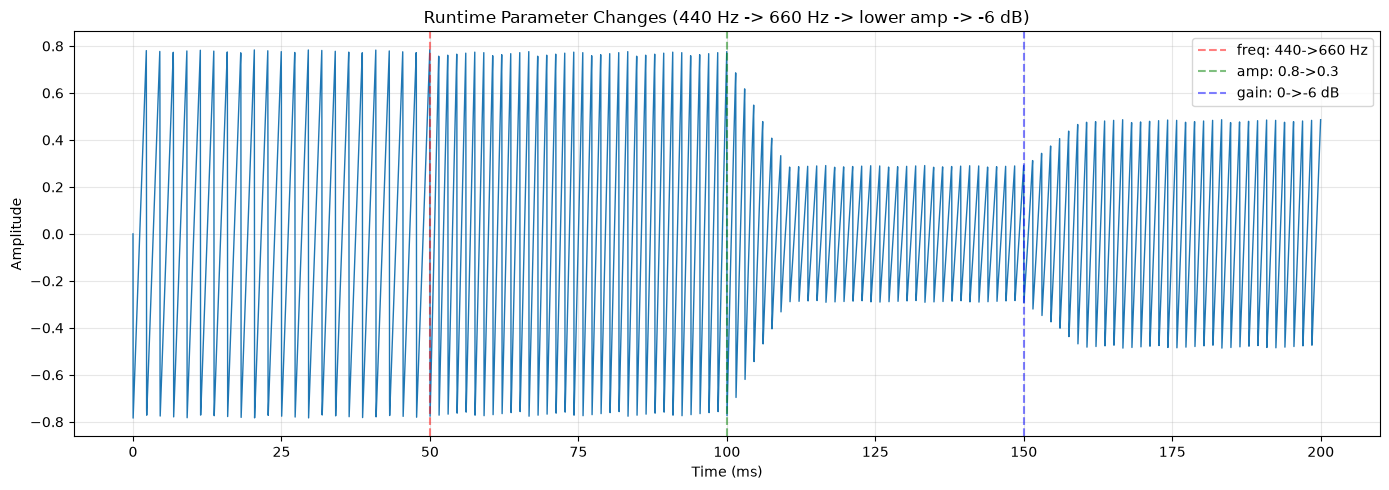

OK Runtime parameter changes:
  0-50ms:   440 Hz, amplitude 0.8
  50-100ms: 660 Hz, amplitude 0.8
  100-150ms: 660 Hz, amplitude 0.3 (smoothed transition)
  150-200ms: 660 Hz, gain -6 dB


In [6]:
osc = PolyBLEPOscillator(
    frequency=440,
    amplitude=0.8,
    gain_db=None,
    sample_rate=SAMPLE_RATE,
    wave_shape=WaveShape.SAWTOOTH_UP,
)

# Generate initial samples
segment = int(SAMPLE_RATE * 0.05)  # 50ms
samples1 = osc.get_samples(segment)

# Change frequency
osc.frequency = 660
samples2 = osc.get_samples(segment)

# Change amplitude (with smoothing)
osc.amplitude = 0.3
samples3 = osc.get_samples(segment)

# Change gain_db
osc.gain_db = -6
samples4 = osc.get_samples(segment)

# Combine all segments
all_samples = np.concatenate([samples1, samples2, samples3, samples4])
time = np.arange(len(all_samples)) / SAMPLE_RATE * 1000

plt.figure(figsize=(14, 5))
plt.plot(time, all_samples, linewidth=1)
plt.axvline(x=50, color="r", linestyle="--", alpha=0.5, label="freq: 440->660 Hz")
plt.axvline(x=100, color="g", linestyle="--", alpha=0.5, label="amp: 0.8->0.3")
plt.axvline(x=150, color="b", linestyle="--", alpha=0.5, label="gain: 0->-6 dB")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Runtime Parameter Changes (440 Hz -> 660 Hz -> lower amp -> -6 dB)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("OK Runtime parameter changes:")
print("  0-50ms:   440 Hz, amplitude 0.8")
print("  50-100ms: 660 Hz, amplitude 0.8")
print("  100-150ms: 660 Hz, amplitude 0.3 (smoothed transition)")
print("  150-200ms: 660 Hz, gain -6 dB")

## 6. Wave Range Conversion

The `wave_range` parameter maps the output to a different range.
This is useful for LFOs (e.g., mapping to 0-1 for modulating filter cutoff).

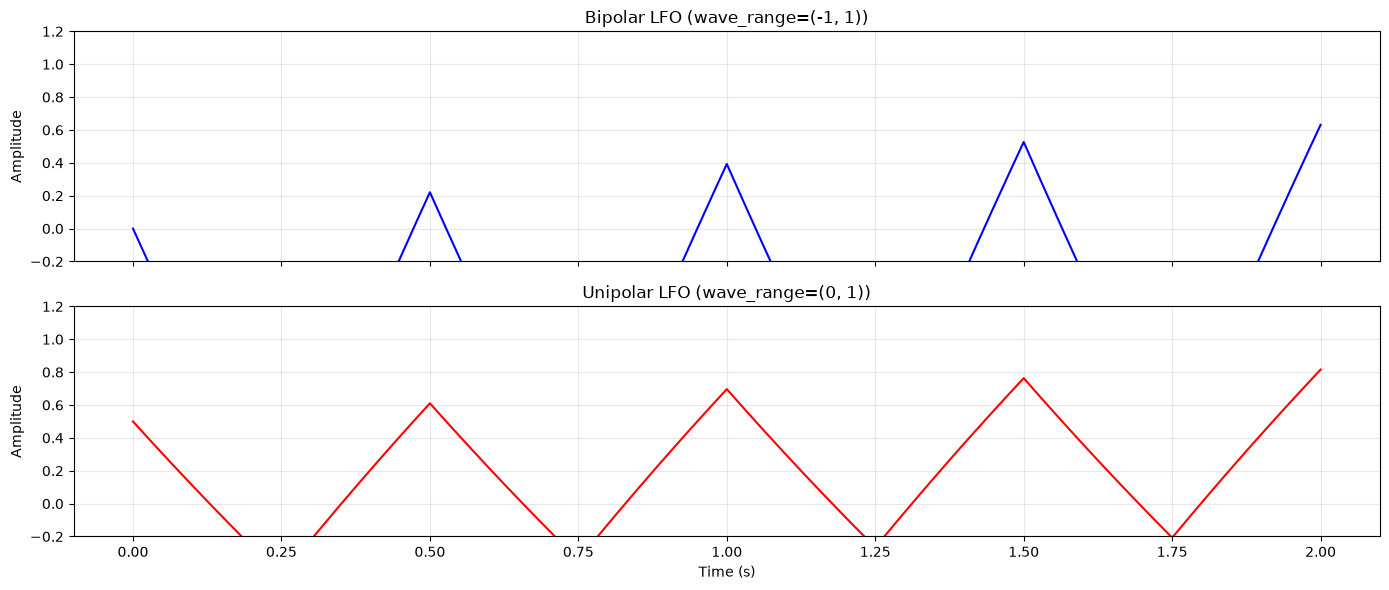

OK Wave range conversion:
  (-1, 1): Standard bipolar output for audio
  (0, 1):  Unipolar output for LFO modulation


In [7]:
freq = 2  # 2 Hz LFO
duration = 2.0
n_samples = int(SAMPLE_RATE * duration)
time = np.arange(n_samples) / SAMPLE_RATE

# Bipolar (-1 to 1)
osc_bipolar = PolyBLEPOscillator(
    frequency=freq,
    amplitude=1.0,
    gain_db=None,
    sample_rate=SAMPLE_RATE,
    wave_shape=WaveShape.TRIANGLE,
    wave_range=(-1, 1),
)
samples_bipolar = osc_bipolar.get_samples(n_samples)

# Unipolar (0 to 1)
osc_unipolar = PolyBLEPOscillator(
    frequency=freq,
    amplitude=1.0,
    gain_db=None,
    sample_rate=SAMPLE_RATE,
    wave_shape=WaveShape.TRIANGLE,
    wave_range=(0, 1),
)
samples_unipolar = osc_unipolar.get_samples(n_samples)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(time, samples_bipolar, "b-", linewidth=1.5)
ax1.set_title("Bipolar LFO (wave_range=(-1, 1))")
ax1.set_ylabel("Amplitude")
ax1.set_ylim(-0.2, 1.2)
ax1.grid(True, alpha=0.3)

ax2.plot(time, samples_unipolar, "r-", linewidth=1.5)
ax2.set_title("Unipolar LFO (wave_range=(0, 1))")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Amplitude")
ax2.set_ylim(-0.2, 1.2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("OK Wave range conversion:")
print("  (-1, 1): Standard bipolar output for audio")
print("  (0, 1):  Unipolar output for LFO modulation")

## 7. Convenience Functions

Quick one-shot generation functions for each waveform type.

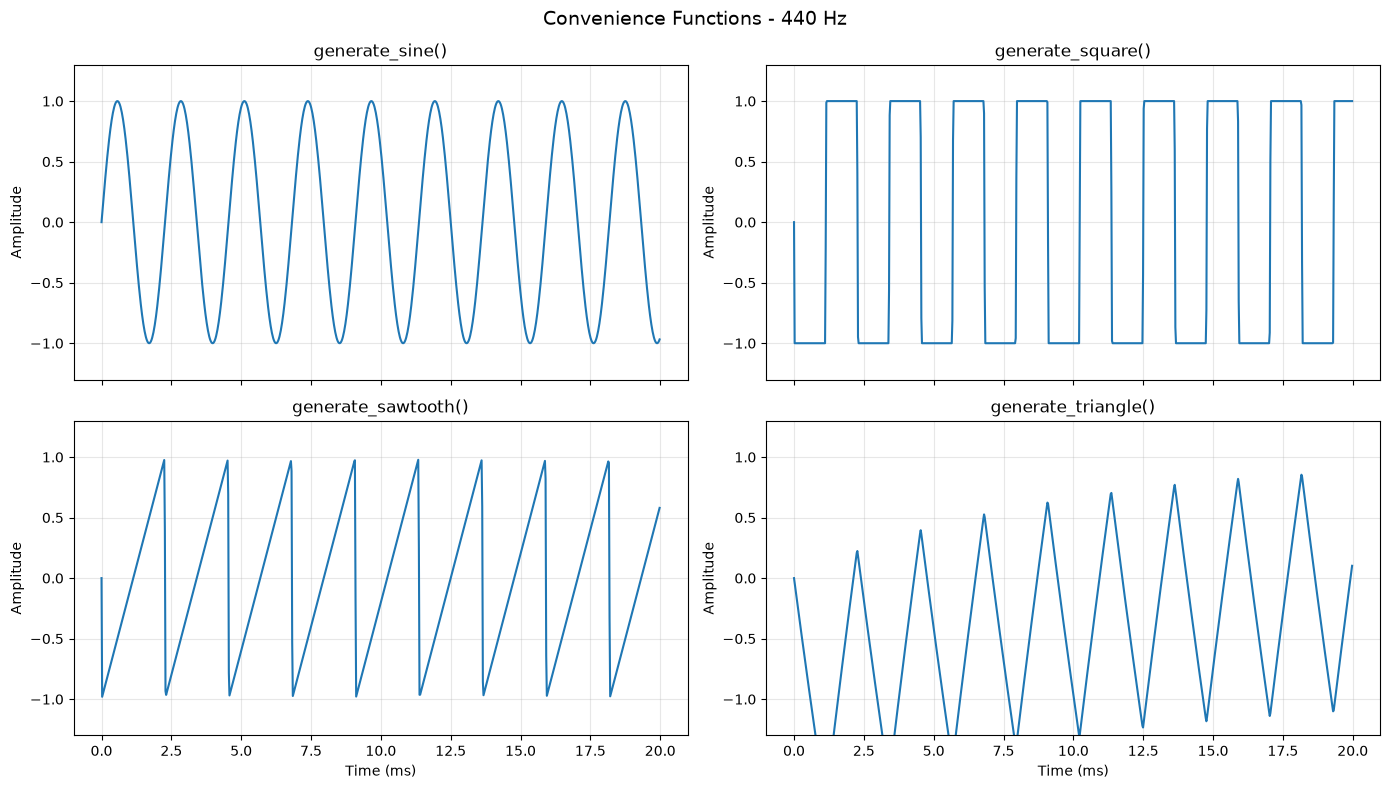

OK Convenience functions:
  generate_sine(frequency, duration, sample_rate, amplitude)
  generate_square(frequency, duration, sample_rate, amplitude, pulsewidth)
  generate_sawtooth(frequency, duration, sample_rate, amplitude)
  generate_triangle(frequency, duration, sample_rate, amplitude)


In [8]:
from src.engine.generators.oscillators.oscillator_polyblep import (
    generate_sawtooth,
    generate_sine,
    generate_square,
    generate_triangle,
)

freq = 440
duration = 0.02
time = np.arange(int(SAMPLE_RATE * duration)) / SAMPLE_RATE * 1000

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle(f"Convenience Functions - {freq} Hz", fontsize=14)

functions = [
    (generate_sine, "generate_sine()"),
    (generate_square, "generate_square()"),
    (generate_sawtooth, "generate_sawtooth()"),
    (generate_triangle, "generate_triangle()"),
]

for ax, (func, name) in zip(axes.flat, functions, strict=False):
    samples = func(freq, duration, SAMPLE_RATE, amplitude=1.0)
    ax.plot(time, samples, linewidth=1.5)
    ax.set_title(name)
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.3, 1.3)

axes[-1, 0].set_xlabel("Time (ms)")
axes[-1, 1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

print("OK Convenience functions:")
print("  generate_sine(frequency, duration, sample_rate, amplitude)")
print("  generate_square(frequency, duration, sample_rate, amplitude, pulsewidth)")
print("  generate_sawtooth(frequency, duration, sample_rate, amplitude)")
print("  generate_triangle(frequency, duration, sample_rate, amplitude)")

## 8. Audio Playback

Listen to the PolyBLEP oscillator output. Each waveform plays for 1 second.

In [9]:
freq = 440
duration = 1.0
n_samples = int(SAMPLE_RATE * duration)

wave_types = [
    (WaveShape.SINE, "Sine"),
    (WaveShape.SQUARE, "Square"),
    (WaveShape.SAWTOOTH_UP, "Sawtooth"),
    (WaveShape.TRIANGLE, "Triangle"),
]

for shape, name in wave_types:
    osc = PolyBLEPOscillator(
        frequency=freq,
        amplitude=0.5,
        gain_db=None,
        sample_rate=SAMPLE_RATE,
        wave_shape=shape,
    )
    samples = osc.get_samples(n_samples)
    print(f"Playing {name} wave ({freq} Hz)...")
    sd.play(samples, SAMPLE_RATE, blocking=True)

print("OK Audio playback complete")

Playing Sine wave (440 Hz)...
Playing Square wave (440 Hz)...
Playing Sawtooth wave (440 Hz)...
Playing Triangle wave (440 Hz)...
OK Audio playback complete


## 9. Pulse Width Sweep

Modulate the pulse width over time to hear the timbral change.

In [10]:
freq = 220
duration = 3.0
n_samples = int(SAMPLE_RATE * duration)

osc = PolyBLEPOscillator(
    frequency=freq,
    amplitude=0.5,
    gain_db=None,
    sample_rate=SAMPLE_RATE,
    wave_shape=WaveShape.SQUARE,
    pulsewidth=0.1,
)

samples = np.zeros(n_samples, dtype=np.float32)
pw_values = np.linspace(0.1, 0.9, n_samples)

# Generate sample by sample to change pulsewidth
for i in range(n_samples):
    osc.pulsewidth = float(pw_values[i])
    samples[i] = next(osc)

print(f"Playing pulse width sweep ({freq} Hz, pw: 0.1 -> 0.9)...")
sd.play(samples, SAMPLE_RATE, blocking=True)
print("OK Done")

Playing pulse width sweep (220 Hz, pw: 0.1 -> 0.9)...
OK Done


## 10. Wave Shape Switching

Switch between wave shapes at runtime without recreating the oscillator.

  Sine: -0.500 to 0.500
  Square: -0.500 to 0.500
  Sawtooth Up: -0.493 to 0.493
  Sawtooth Down: -0.493 to 0.493
  Triangle: -0.930 to 0.496


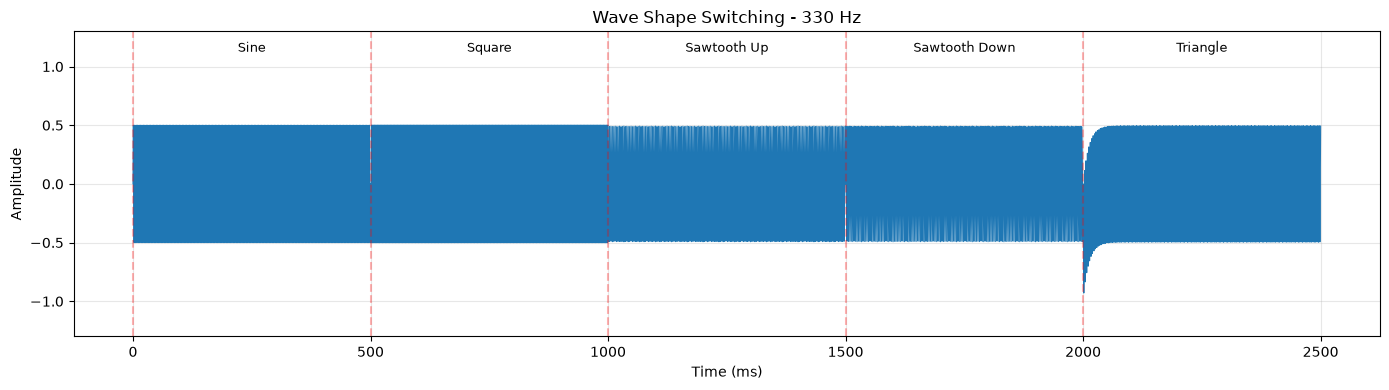


Playing wave shape sequence...
OK Done


In [11]:
freq = 330
segment_dur = 0.5
segment_samples = int(SAMPLE_RATE * segment_dur)

shapes = [
    (WaveShape.SINE, "Sine"),
    (WaveShape.SQUARE, "Square"),
    (WaveShape.SAWTOOTH_UP, "Sawtooth Up"),
    (WaveShape.SAWTOOTH_DOWN, "Sawtooth Down"),
    (WaveShape.TRIANGLE, "Triangle"),
]

osc = PolyBLEPOscillator(
    frequency=freq,
    amplitude=0.5,
    gain_db=None,
    sample_rate=SAMPLE_RATE,
    wave_shape=WaveShape.SINE,
)

all_samples = []
for shape, name in shapes:
    osc.wave_shape = shape
    iter(osc)  # reset phase
    seg = osc.get_samples(segment_samples)
    all_samples.append(seg)
    print(f"  {name}: {seg.min():.3f} to {seg.max():.3f}")

combined = np.concatenate(all_samples)
time = np.arange(len(combined)) / SAMPLE_RATE * 1000

plt.figure(figsize=(14, 4))
plt.plot(time, combined, linewidth=0.8)
for i, (_, name) in enumerate(shapes):
    plt.axvline(x=i * segment_dur * 1000, color="r", linestyle="--", alpha=0.3)
    plt.text(
        (i + 0.5) * segment_dur * 1000,
        1.1,
        name,
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title(f"Wave Shape Switching - {freq} Hz")
plt.ylim(-1.3, 1.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPlaying wave shape sequence...")
sd.play(combined, SAMPLE_RATE, blocking=True)
print("OK Done")